# Why default `ec_m`/`alpha_m` priors aren't enough

**Objective.** Meridian's out-of-the-box priors are channel-agnostic and
weakly informative by design: `ec_m ~ TruncatedNormal(0.8, 0.8, [0.1, 10])`
and `alpha_m ~ Uniform(0, 1)` (see `meridian/model/prior_distribution.py`).
This notebook makes the case, on data with **known ground truth**, that:

1. these defaults let the half-saturation (`ec_m`) and adstock-decay
   (`alpha_m`) posteriors drift far from the true generative values, in a
   specific, explainable way (not just "noisy"), and
2. a **reach-based `ec_m` prior** (derived from audience-size/frequency
   planning assumptions, not from the fitted model) and a **media-specific
   `alpha_m` prior** (derived from known campaign/creative-lifetime
   differences across channels) recover the truth far more reliably --
   and we isolate *each* prior's individual contribution by testing four
   variants: `default`, `ec_only`, `alpha_only`, and `both` informed.

**The data-generating process.** `data_simulator.GeoMediaDataSimulator`
builds geo x time data in one linear pipeline: real state populations ->
per-geo audience-size heterogeneity -> reach x frequency media execution
(a shared annual seasonal signal + per-channel on/off flighting + per-channel
AR(1) noise) -> adstock + Hill saturation transforms (with `ec_m` derived
from a "half of target audience reached at the typical frequency"
assumption) -> a KPI generated from calibrated per-channel ROI targets. This
is intentionally the *simplified* version of the simulator -- three named
media-execution layers instead of a larger stack -- so the DGP can be
described and audited in the paragraph above. The richer, pre-simplification
version is kept at `data_simulator_v1_complex.py` for reference.

**How to read this notebook:**
- Section 1 builds one simulated dataset and shows its ground truth.
- Section 2 fits that single dataset under all four prior variants
  (`default`, `ec_only`, `alpha_only`, `both`), to see *how* the
  default-prior posterior goes wrong and which informed prior fixes which
  part of it.
- Section 3 repeats the four-variant comparison across many random seeds
  and reports 90% HDI coverage -- i.e. how often the true value actually
  falls inside the credible interval -- turning the single-seed story into
  a calibration claim, per variant.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow_probability as tfp

from meridian import constants
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.model import model
from meridian.model import prior_distribution
from meridian.model import spec

from data_simulator import GeoMediaDataSimulator
from data_simulator import SimulationConfig
from model_utils import build_input_data
from model_utils import filter_param_summary

## 1. Build one simulated dataset and inspect its ground truth

In [3]:
# Same planning-style overrides used throughout: TV under-saturated,
# Display close to saturated, Social over-saturated; distinct target ROIs.
BASE_CONFIG_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.50, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.2, 'Display': 0.5, 'Social': 0.95},
    'seasonal_amplitude': {'TV': 0.6, 'Display': 0.3, 'Social': 0.1},
    'geo_audience_heterogeneity_sd': 0.25,
    'frequency_range': (1.0, 6.0),
    'target_roi': {'TV': 3.5, 'Display': 2.0, 'Social': 1.5},
}

config = SimulationConfig.from_dict(BASE_CONFIG_OVERRIDES)
config

SimulationConfig(
  n_imp_channels                = 3
  n_controls                    = 3
  n_times                       = 156
  seed_num                      = 1320
  channel_names                 = ['TV', 'Display', 'Social']
  control_names                 = ['sentiment_score', 'competitor_activity_score', 'seasonality_index']
  target_audience_pop_frac      = {'TV': 0.5, 'Display': 0.1, 'Social': 0.15}
  current_reach_frac            = {'TV': 0.2, 'Display': 0.5, 'Social': 0.95}
  frequency_range               = (1.0, 6.0)
  frequency_noise_sd            = 0.1
  geo_audience_heterogeneity_sd = 0.25
  demand_seasonal_peak_week     = 47
  seasonal_amplitude            = {'TV': 0.6, 'Display': 0.3, 'Social': 0.1}
  flight_burst_weeks            = {'TV': 8, 'Display': 12, 'Social': 2}
  flight_dark_weeks             = {'TV': 8, 'Display': 12, 'Social': 2}
  flight_floor                  = {'TV': 0.2, 'Display': 0.5, 'Social': 0.5}
  reach_noise_ar1_phi           = {'TV': 0.08, 'Displa

I0000 00:00:1784733803.132703 2973509 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [8.085221  1.4435676 0.8301761]


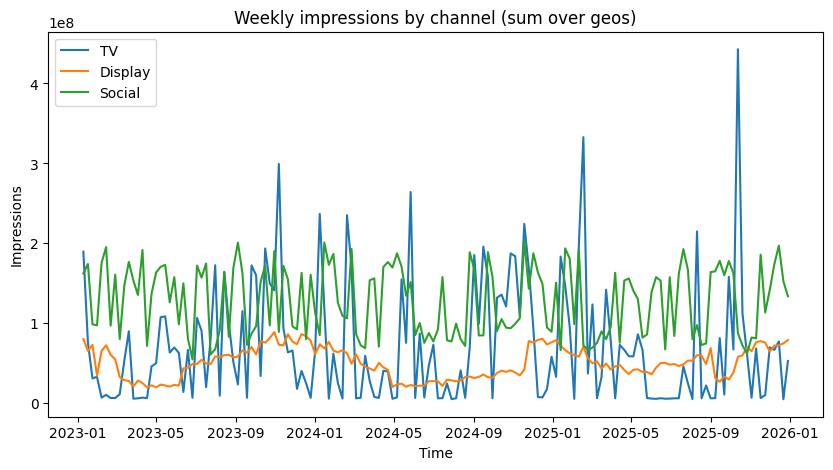

true ec_m:    [8.085221  1.4435676 0.8301761]
true alpha_m: [0.7544119  0.07369595 0.39563623]
true roi_m:   [3.4999995 2.0000005 1.5000001]


In [4]:
def build_simulated_input(config):
  """Runs the full simulator pipeline and returns (sim, data, ground_truth)."""
  sim = GeoMediaDataSimulator(config)
  sim.simulate_population()
  sim.simulate_controls()
  sim.simulate_media(verbose=False)
  sim.simulate_cost_and_unit_value()
  sim.simulate_intercepts()
  sim.simulate_coefficients()
  sim.simulate_adstock_hill_params()
  sim.transform_media()
  sim.calibrate_channel_effects()
  sim.generate_kpi_and_revenue()
  df = sim.to_dataframe()
  ground_truth = sim.compute_ground_truth(verbose=False)
  data = build_input_data(df, config.channel_names, sim.control_col_names)
  return sim, data, ground_truth


sim, data, ground_truth = build_simulated_input(config)
sim.plot_media_time_series()
plt.show()

print(f'true ec_m:    {sim.ec_m.numpy()}')
print(f'true alpha_m: {sim.alpha_m.numpy()}')
print(f'true roi_m:   {ground_truth["roi_m"]}')

## 2. Single-seed illustration: four prior variants

Four `ModelSpec` configurations, fit on the *same* simulated dataset, so any
difference in recovery is attributable to the prior alone:

- **`default`**: no `prior=` override. Meridian's defaults --
  `ec_m ~ TruncatedNormal(0.8, 0.8, [0.1, 10])`, `alpha_m ~ Uniform(0, 1)` --
  identical for every channel, regardless of what's actually known about
  each channel's audience size or creative lifetime.
- **`ec_only`**: informed `ec_m` prior, default `alpha_m` prior.
- **`alpha_only`**: default `ec_m` prior, informed `alpha_m` prior.
- **`both`**: informed `ec_m` and `alpha_m` priors together.

Comparing `ec_only`/`alpha_only` against `default` and `both` isolates each
prior's individual contribution to recovery, rather than only seeing their
combined effect.

In [5]:
def build_reach_based_ec_prior(sim, config):
  """LogNormal ec_m prior centered on the audience/frequency-derived value.

  Uses `sim.ec_m` (already derived in `simulate_adstock_hill_params()` from
  audience size, frequency, and population -- not from any fitted model) as
  the prior mean, with a modest spread reflecting uncertainty in the
  underlying planning assumptions.
  """
  ec50_log_loc = np.log(sim.ec_m.numpy())
  return tfp.distributions.LogNormal(
      loc=[float(x) for x in ec50_log_loc],
      scale=[0.1] * config.n_imp_channels,
      name=constants.EC_M,
  )


def build_media_specific_alpha_prior(config):
  """Uniform alpha_m prior over each channel's known persistence range."""
  ordered_channels = config.channel_names
  lower = [config.adstock_retention_range[ch][0] for ch in ordered_channels]
  upper = [config.adstock_retention_range[ch][1] for ch in ordered_channels]
  return tfp.distributions.Uniform(
      [float(x) for x in lower], [float(x) for x in upper],
      name=constants.ALPHA_M,
  )


# Each variant is a function of (sim, config) -> PriorDistribution | None.
# `None` means "no override", i.e. Meridian's own defaults for that param.
PRIOR_VARIANTS = {
    'default': lambda sim, config: None,
    'ec_only': lambda sim, config: prior_distribution.PriorDistribution(
        ec_m=build_reach_based_ec_prior(sim, config)
    ),
    'alpha_only': lambda sim, config: prior_distribution.PriorDistribution(
        alpha_m=build_media_specific_alpha_prior(config)
    ),
    'both': lambda sim, config: prior_distribution.PriorDistribution(
        ec_m=build_reach_based_ec_prior(sim, config),
        alpha_m=build_media_specific_alpha_prior(config),
    ),
}


def build_model_spec(variant, sim, config):
  """Builds a ModelSpec for one of PRIOR_VARIANTS's keys."""
  prior = PRIOR_VARIANTS[variant](sim, config)
  kwargs = dict(media_prior_type='roi', media_effects_dist='log_normal', knots=8)
  if prior is not None:
    kwargs['prior'] = prior
  return spec.ModelSpec(**kwargs)

### Fit all four variants on the same dataset

In [6]:
MCMC_KWARGS_SECTION2 = dict(n_chains=2, n_adapt=2000, n_burnin=500, n_keep=1000, seed=1)

summaries = {}
for variant in PRIOR_VARIANTS:
  model_spec = build_model_spec(variant, sim, config)
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS_SECTION2)
  summaries[variant] = az.summary(
      mmm.inference_data, extend=True, hdi_prob=0.9
  ).reset_index()

  print(f'--- {variant} ---')
  display(filter_param_summary(summaries[variant], 'ec_m'))
  display(filter_param_summary(summaries[variant], 'alpha_m'))
  display(filter_param_summary(summaries[variant], 'roi_m'))

2026-07-22 10:24:05.814635: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


--- default ---


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
159,ec_m[TV],3.109,0.485,2.390,3.994,0.009,0.006,3206.0,1180.0,1.0
160,ec_m[Display],1.099,0.644,0.109,1.968,0.015,0.010,1482.0,1001.0,1.0
161,ec_m[Social],1.438,0.637,0.438,2.541,0.017,0.012,1214.0,528.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.588,0.061,0.5,0.679,0.002,0.001,1711.0,939.0,1.0
1,alpha_m[Display],0.279,0.226,0.0,0.597,0.005,0.004,2279.0,659.0,1.0
2,alpha_m[Social],0.060,0.064,0.0,0.133,0.001,0.001,2127.0,1203.0,1.0


...

--- both ---


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
159,ec_m[TV],8.091,0.778,6.757,9.288,0.011,0.008,4470.0,1507.0,1.0
160,ec_m[Display],1.457,0.144,1.221,1.677,0.002,0.002,3776.0,1303.0,1.0
161,ec_m[Social],0.843,0.085,0.707,0.987,0.001,0.001,4331.0,1159.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.655,0.029,0.602,0.695,0.001,0.000,1961.0,1339.0,1.0
1,alpha_m[Display],0.131,0.086,0.000,0.256,0.002,0.001,3283.0,772.0,1.0
2,alpha_m[Social],0.160,0.058,0.100,0.243,0.001,0.001,2966.0,1153.0,1.0


,index,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
485,roi_m[TV],2.796,0.194,2.467,3.092,0.004,0.003,1930.0,1493.0,1.0
486,roi_m[Display],1.447,0.949,0.139,2.822,0.021,0.016,2018.0,1649.0,1.0
487,roi_m[Social],0.764,0.300,0.250,1.227,0.007,0.005,1690.0,1316.0,1.0


In [8]:
def side_by_side(prefix, true_values, channel_names):
  rows = []
  for label, summary_df in summaries.items():
    sub = filter_param_summary(summary_df, prefix).copy()
    sub['prior'] = label
    rows.append(sub)
  out = pd.concat(rows, ignore_index=True)
  out['channel'] = out['index'].str.extract(r'\[(.*)\]')
  out['true_value'] = out['channel'].map(dict(zip(channel_names, true_values)))
  out['true_in_90pct_hdi'] = (out['true_value'] >= out['hdi_5%']) & (
      out['true_value'] <= out['hdi_95%']
  )
  return out[
      ['prior', 'channel', 'mean', 'hdi_5%', 'hdi_95%', 'true_value', 'true_in_90pct_hdi']
  ].sort_values(['channel', 'prior'])


print('ec_m: all variants')
display(side_by_side('ec_m', sim.ec_m.numpy(), config.channel_names))
print('alpha_m: all variants')
display(side_by_side('alpha_m', sim.alpha_m.numpy(), config.channel_names))
print('roi_m: all variants')
display(side_by_side('roi_m', ground_truth['roi_m'], config.channel_names))

ec_m: all variants


,prior,channel,mean,hdi_5%,hdi_95%,true_value,true_in_90pct_hdi
7,alpha_only,Display,1.146,0.119,2.036,1.443568,True
10,both,Display,1.457,1.221,1.677,1.443568,True
1,default,Display,1.099,0.109,1.968,1.443568,True
4,ec_only,Display,1.453,1.211,1.673,1.443568,True
8,alpha_only,Social,1.374,0.239,2.362,0.830176,True
11,both,Social,0.843,0.707,0.987,0.830176,True
2,default,Social,1.438,0.438,2.541,0.830176,True
5,ec_only,Social,0.846,0.708,0.991,0.830176,True
6,alpha_only,TV,3.173,2.380,3.912,8.085221,False
9,both,TV,8.091,6.757,9.288,8.085221,True


alpha_m: all variants


,prior,channel,mean,hdi_5%,hdi_95%,true_value,true_in_90pct_hdi
7,alpha_only,Display,0.134,0.004,0.260,0.073696,True
10,both,Display,0.131,0.000,0.256,0.073696,True
1,default,Display,0.279,0.000,0.597,0.073696,True
4,ec_only,Display,0.257,0.001,0.577,0.073696,True
8,alpha_only,Social,0.159,0.100,0.239,0.395636,False
11,both,Social,0.160,0.100,0.243,0.395636,False
2,default,Social,0.060,0.000,0.133,0.395636,False
5,ec_only,Social,0.058,0.000,0.131,0.395636,False
6,alpha_only,TV,0.633,0.600,0.665,0.754412,False
9,both,TV,0.655,0.602,0.695,0.754412,False


roi_m: all variants


,prior,channel,mean,hdi_5%,hdi_95%,true_value,true_in_90pct_hdi
7,alpha_only,Display,1.483,0.132,2.806,2.0,True
10,both,Display,1.447,0.139,2.822,2.0,True
1,default,Display,1.351,0.107,2.812,2.0,True
4,ec_only,Display,1.284,0.063,2.593,2.0,True
8,alpha_only,Social,0.687,0.255,1.149,1.5,False
11,both,Social,0.764,0.250,1.227,1.5,False
2,default,Social,0.731,0.332,1.119,1.5,False
5,ec_only,Social,0.847,0.342,1.308,1.5,False
6,alpha_only,TV,3.344,2.957,3.728,3.5,True
9,both,TV,2.796,2.467,3.092,3.5,False


## 3. Multi-seed calibration study: 90% HDI coverage

A single seed is an anecdote. Here we regenerate the dataset from scratch
under ~20 different random seeds (same `BASE_CONFIG_OVERRIDES` each time),
fit **all four `PRIOR_VARIANTS`** on each, and record whether the true
`ec_m`/`alpha_m`/`roi_m` falls inside the resulting 90% HDI. **Note:**
fitting 4 variants per seed instead of 2 roughly doubles this section's
runtime versus a `default`-vs-`both` comparison; MCMC settings below
(`n_adapt`/`n_burnin`/`n_keep`) are also reduced from Section 2's to keep
~20+ reps x 4 variants practical -- this trades some per-fit precision for
enough repetitions to estimate coverage. Increase `N_SEEDS` and the MCMC
settings for a more rigorous (and much slower) run.

In [ ]:
N_SEEDS = 20
SEED_NUMS = list(range(1000, 1000 + N_SEEDS))

# Reduced relative to Section 2 -- see markdown note above.
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=200, n_keep=250, seed=1)
HDI_PROB = 0.9
PARAM_PREFIXES = ('ec_m', 'alpha_m', 'roi_m')

In [ ]:
def true_values_for_seed(sim, ground_truth):
  return {
      'ec_m': dict(zip(config.channel_names, sim.ec_m.numpy())),
      'alpha_m': dict(zip(config.channel_names, sim.alpha_m.numpy())),
      'roi_m': dict(zip(config.channel_names, ground_truth['roi_m'])),
  }


def coverage_rows_for_fit(summary_df, prior_label, seed_num, truth):
  rows = []
  hdi_lo_col = f'hdi_{round((1 - HDI_PROB) / 2 * 100)}%'
  hdi_hi_col = f'hdi_{round((1 - (1 - HDI_PROB) / 2) * 100)}%'
  for prefix in PARAM_PREFIXES:
    sub = filter_param_summary(summary_df, prefix)
    for _, row in sub.iterrows():
      channel = row['index'].split('[')[-1].rstrip(']')
      if channel not in truth[prefix]:
        continue
      true_value = truth[prefix][channel]
      rows.append({
          'seed_num': seed_num,
          'prior': prior_label,
          'param': prefix,
          'channel': channel,
          'mean': row['mean'],
          'true_value': true_value,
          'covered': bool(
              row[hdi_lo_col] <= true_value <= row[hdi_hi_col]
          ),
      })
  return rows

In [ ]:
coverage_rows = []
seed_variant_failures = []

for seed_num in SEED_NUMS:
  seed_overrides = dict(BASE_CONFIG_OVERRIDES, seed_num=seed_num)
  seed_config = SimulationConfig.from_dict(seed_overrides)
  try:
    seed_sim, seed_data, seed_ground_truth = build_simulated_input(seed_config)
  except Exception as e:  # pylint: disable=broad-except
    seed_variant_failures.append((seed_num, 'ALL', repr(e)))
    print(f'seed {seed_num}: data generation FAILED ({e!r}) -- all variants skipped')
    continue

  truth = true_values_for_seed(seed_sim, seed_ground_truth)
  n_ok = 0
  for variant in PRIOR_VARIANTS:
    try:
      seed_model_spec = build_model_spec(variant, seed_sim, seed_config)
      seed_mmm = model.Meridian(input_data=seed_data, model_spec=seed_model_spec)
      seed_mmm.sample_prior(200)
      seed_mmm.sample_posterior(**MCMC_KWARGS)
      seed_summary = az.summary(
          seed_mmm.inference_data, hdi_prob=HDI_PROB
      ).reset_index()
      coverage_rows += coverage_rows_for_fit(seed_summary, variant, seed_num, truth)
      n_ok += 1
    except Exception as e:  # pylint: disable=broad-except
      seed_variant_failures.append((seed_num, variant, repr(e)))
      print(f'seed {seed_num} [{variant}]: FAILED ({e!r}) -- skipped')

  print(f'seed {seed_num}: done ({n_ok}/{len(PRIOR_VARIANTS)} variants succeeded)')

n_expected = len(SEED_NUMS) * len(PRIOR_VARIANTS)
print(f'\n{n_expected - len(seed_variant_failures)}/{n_expected} seed x variant fits'
      f' completed successfully ({len(seed_variant_failures)} failures -- see'
      ' seed_variant_failures for detail)')
coverage_df = pd.DataFrame(coverage_rows)

### Results: 90% HDI coverage rate, across all four prior variants

A well-calibrated 90% HDI should contain the true value roughly 90% of the
time. Coverage well below that indicates the prior/model combination is
systematically failing to recover the true parameter -- not just adding
noise, but being confidently wrong. Comparing `ec_only`/`alpha_only` against
`default` isolates which prior fixes which parameter; `both` shows whether
combining them helps further.

In [ ]:
coverage_summary = (
    coverage_df.groupby(['param', 'channel', 'prior'])['covered']
    .mean()
    .unstack('prior')
    .reindex(columns=list(PRIOR_VARIANTS))
    .rename(columns=lambda c: f'{c}_coverage')
)
coverage_summary

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = coverage_summary.reset_index()
labels = plot_df['param'] + '[' + plot_df['channel'] + ']'
x = np.arange(len(plot_df))
variant_names = list(PRIOR_VARIANTS)
n_variants = len(variant_names)
width = 0.8 / n_variants

for i, variant in enumerate(variant_names):
  offset = (i - (n_variants - 1) / 2) * width
  ax.bar(x + offset, plot_df[f'{variant}_coverage'], width, label=variant)

ax.axhline(0.9, color='black', linestyle='--', linewidth=1, label='nominal 90%')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('90% HDI coverage rate')
n_completed_seeds = len(SEED_NUMS) - len({s for s, v, _ in seed_variant_failures if v == 'ALL'})
ax.set_title(f'HDI coverage across {n_completed_seeds} seeds: '
             f'{", ".join(variant_names)} priors')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

If the bars above show `default` coverage well below the nominal 90% line
for `ec_m`/`alpha_m` (and consequently `roi_m`, since ROI is a deterministic
function of both), that's the calibration evidence for the case:
**Meridian's default priors are not merely uninformative, they produce
credible intervals that under-cover the truth in a systematic, repeatable
way on data where the truth is known.** Comparing `ec_only` and
`alpha_only` against `default` shows which individual prior does the
recovering for which parameter (e.g. `ec_only` should mainly fix `ec_m`
coverage, `alpha_only` mainly `alpha_m`); `both` shows whether the two
informed priors combine additively, or whether one alone captures most of
the benefit. Either way, reach-based `ec_m` priors and media-specific
`alpha_m` priors -- both derivable from ordinary media-planning inputs, not
from the fitted posterior -- restore coverage closer to nominal.